UNI WORD RECORD 

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [18]:
df = pd.read_csv('UNI.csv')
df['international influence'] = df[['isr score', 'ifr score', 'irn score']].mean(axis=1)

u = df.head(10)
u

,rank,institution,location code,location,ar score,ar rank,er score,er rank,fsr score,fsr rank,...,ifr score,ifr rank,isr score,isr rank,irn score,irn rank,ger score,ger rank,score scaled,international influence
0,1.0,Massachusetts Institute of Technology (MIT),US,United States,100.0,5,100.0,4,100.0,14,...,100.0,54,90.0,109,96.1,58,100.0,3,100.0,95.366667
1,2.0,University of Cambridge,UK,United Kingdom,100.0,2,100.0,2,100.0,11,...,100.0,60,96.3,70,99.5,6,100.0,9,98.8,98.600000
2,3.0,Stanford University,US,United States,100.0,4,100.0,5,100.0,6,...,99.8,74,60.3,235,96.3,55,100.0,2,98.5,85.466667
3,4.0,University of Oxford,UK,United Kingdom,100.0,3,100.0,3,100.0,8,...,98.8,101,98.4,54,99.9,3,100.0,7,98.4,99.033333
4,5.0,Harvard University,US,United States,100.0,1,100.0,1,99.4,35,...,76.9,228,66.9,212,100.0,1,100.0,1,97.6,81.266667
5,6.0,California Institute of Technology (Caltech),US,United States,96.5,28,87.1,58,100.0,3,...,99.8,75,85.1,134,73.0,425,98.8,24,97.0,85.966667
6,7.0,Imperial College London,UK,United Kingdom,98.3,24,99.7,10,99.5,34,...,100.0,55,100.0,13,98.1,20,88.8,76,97.0,99.366667
7,8.0,UCL,UK,United Kingdom,99.4,14,98.6,16,97.6,51,...,99.2,87,100.0,14,100.0,2,90.3,71,95.0,99.733333
8,9.0,ETH Zurich - Swiss Federal Institute of Techno...,CH,Switzerland,98.6,18,91.3,51,74.2,164,...,100.0,24,98.0,59,96.2,56,91.1,64,93.6,98.066667
9,10.0,University of Chicago,US,United States,99.2,16,92.2,46,92.9,71,...,81.6,214,76.0,176,89.6,170,98.2,30,93.2,82.400000


Rank
Position of the university in the worldwide ranking

institution
The name of the university/college

location code
Location code of where the university is located

location
Full location name

ar score
academic reputation score

ar rank
academic reputation rank

er score
employer reputation

er rank
employer reputation

fsr score
faculty/student ratio

fsr rank
faculty/student ratio

cpf score
citations per faculty

cpf rank
citations per faculty

ifr score
international faculty ratio

ifr rank
international faculty ratio

isr score
(international student ratio)

isr rank
(international student ratio)

irn score
international research network

irn rank
international research network

ger score
employment outcome

ger rank
employment outcome

score scaled
Score according to the scores obtained

In [19]:
u['ar rank'] = u['ar rank'].str.replace(',', '').astype(float)
u['er rank'] = u['er rank'].str.replace(',', '').astype(float)
u['isr rank'] = u['isr rank'].str.replace(',', '').astype(float)
u['fsr rank'] = u['fsr rank'].str.replace(',', '').astype(float)
u['cpf rank'] = u['cpf rank'].str.replace(',', '').astype(float)
u['ifr rank'] = u['ifr rank'].str.replace(',', '').astype(float)
u['irn rank'] = u['irn rank'].str.replace(',', '').astype(float)
u['ger rank'] = u['ger rank'].str.replace(',', '').astype(float)

C:\Users\Admin\AppData\Local\Temp\ipykernel_26612\3146955754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  u['ar rank'] = u['ar rank'].str.replace(',', '').astype(float)
C:\Users\Admin\AppData\Local\Temp\ipykernel_26612\3146955754.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  u['er rank'] = u['er rank'].str.replace(',', '').astype(float)
C:\Users\Admin\AppData\Local\Temp\ipykernel_26612\3146955754.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

In [20]:
u.dtypes

rank                       float64
institution                 object
location code               object
location                    object
ar score                   float64
ar rank                    float64
er score                   float64
er rank                    float64
fsr score                  float64
fsr rank                   float64
cpf score                  float64
cpf rank                   float64
ifr score                  float64
ifr rank                   float64
isr score                  float64
isr rank                   float64
irn score                  float64
irn rank                   float64
ger score                  float64
ger rank                   float64
score scaled               float64
international influence    float64
dtype: object

Top 10 uni

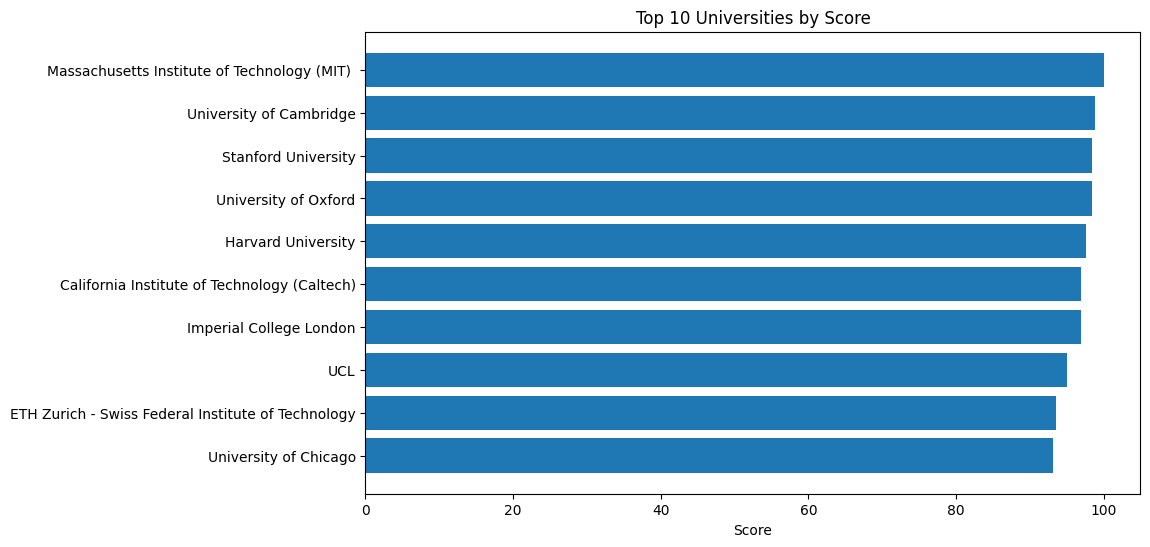

In [21]:
top10 = u.sort_values('score scaled', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['institution'], top10['score scaled'])
plt.gca().invert_yaxis()

plt.xlabel('Score')
plt.title('Top 10 Universities by Score')

plt.show()


- Day la xep hang top 10 university bang score scale

Pie chart truong theo quoc gia 

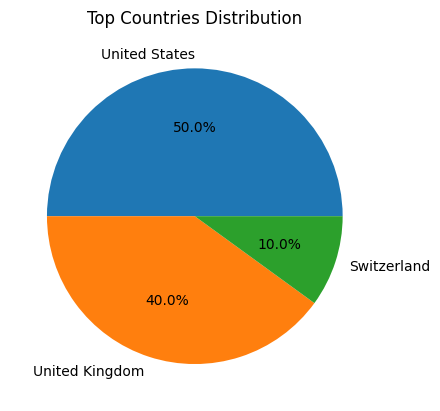

In [22]:
u['location'].value_counts().head(3).plot(kind='pie', autopct='%1.1f%%')

plt.title('Top Countries Distribution')
plt.ylabel('')
plt.show()


- 50% TRUONG TOP LA CUA US
- 40% LA CUA UK
- 10% LA CUA SWITZERLAND

Ty le du hoc sinh voi ranking cua uni

In [23]:
plt.figure(figsize=(10,6))

plt.scatter(u['Rank'], u['isr score'])

plt.xlabel('Rank')
plt.ylabel('International Student Ratio (ISR)')
plt.title('ISR vs Rank')

plt.show()


KeyError: 'Rank'

<Figure size 1000x600 with 0 Axes>

- Ty le du hoc sinh so voi ranking cua Truong 

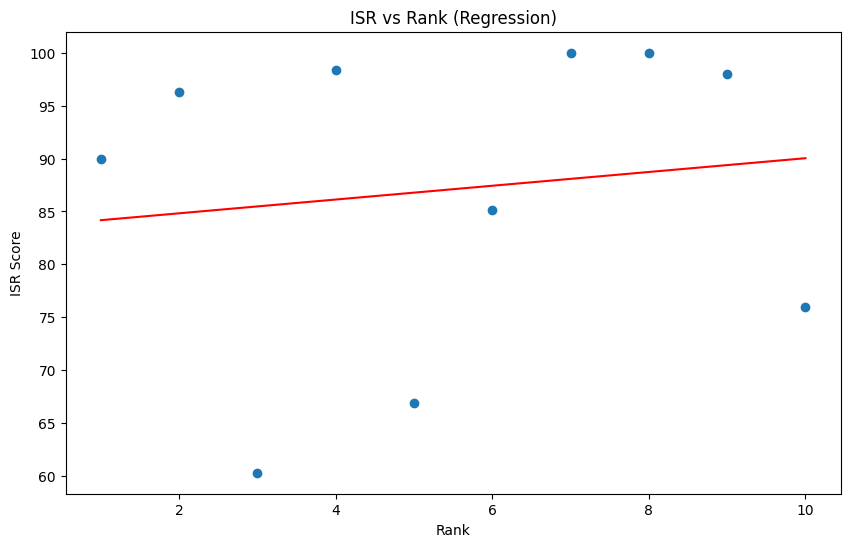

In [ ]:

X = u[['Rank']]
y = u[['isr score']]

model = LinearRegression()
model.fit(X, y)

plt.figure(figsize=(10,6))

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')

plt.xlabel('Rank')
plt.ylabel('ISR Score')
plt.title('ISR vs Rank (Regression)')

plt.show()


- Duong tuyen tinh cho thay Ranking cua truong it lien quan den ty le du hoc sinh

So sanh ty le du hoc sinh cua US vs UK va Switzerland

In [ ]:
countries = ['United States', 'United Kingdom', 'Switzerland']

u_3 = u[u['location'].isin(countries)]
u_3.groupby('location')['isr score'].mean()



location
Switzerland       98.000
United Kingdom    98.675
United States     75.660
Name: isr score, dtype: float64

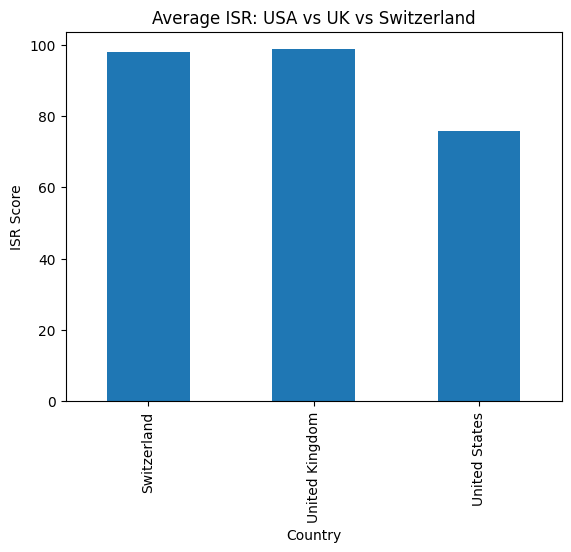

In [ ]:
avg_isr = u_3.groupby('location')['isr score'].mean()

avg_isr.plot(kind='bar')

plt.title('Average ISR: USA vs UK vs Switzerland')
plt.xlabel('Country')
plt.ylabel('ISR Score')

plt.show()


- Ty le trung binh du hoc sinh cua 10 truong top dau o ca 3 quoc gia (US, UK, SWITZERLAND)


Yeu to thu hut du hoc sinh 

In [ ]:
corr = df.corr(numeric_only=True)

corr['isr score'].sort_values(ascending=False)

isr score                  1.000000
international influence    0.850500
ifr score                  0.715603
score scaled               0.406407
ar score                   0.398779
er score                   0.365386
irn score                  0.360347
cpf score                  0.360219
ger score                  0.305670
fsr score                  0.226790
Rank                      -0.527870
Name: isr score, dtype: float64

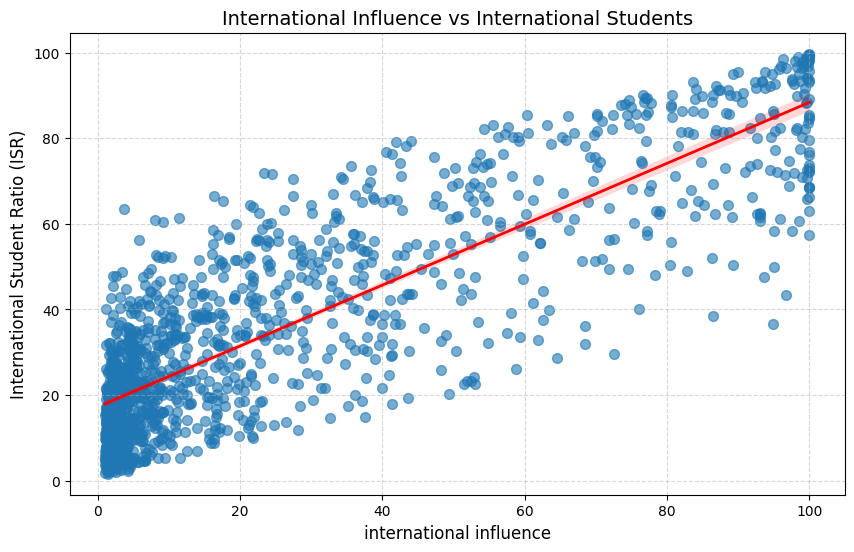

In [ ]:

plt.figure(figsize=(10,6))

sns.regplot(
    x='isr score',
    y='international influence',
    data=df,
    scatter_kws={'alpha':0.6, 's':50},   # điểm rõ hơn
    line_kws={'color':'red', 'linewidth':2}
)

plt.title('International Influence vs International Students', fontsize=14)
plt.xlabel('international influence', fontsize=12)
plt.ylabel('International Student Ratio (ISR)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


- Bieu do cho thay suc anh huong quoc te lien quan mat thiet den su tang truong cua ty le du hoc sinh

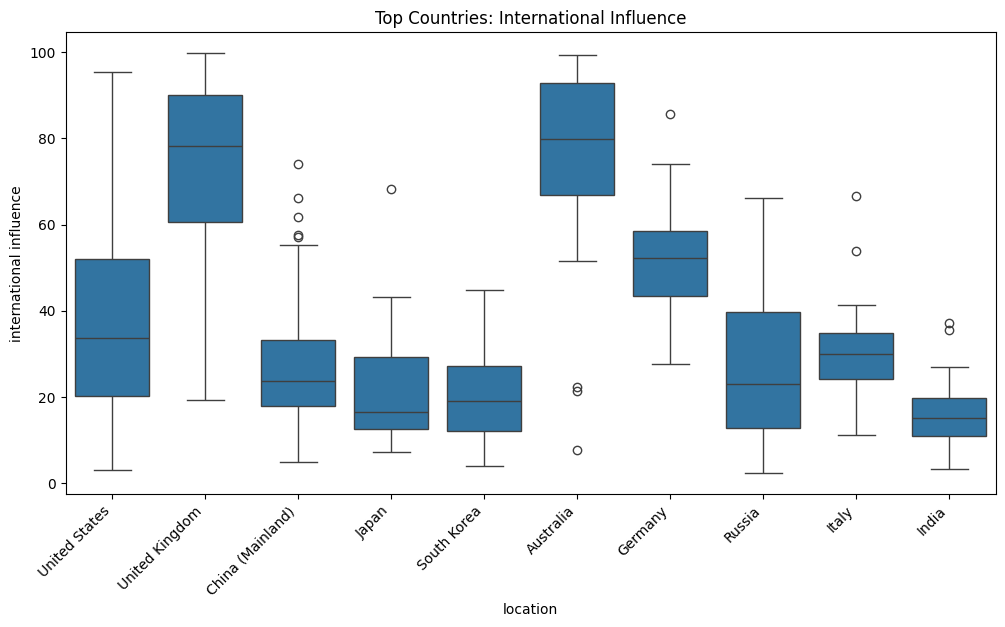

In [ ]:
top_countries = df['location'].value_counts().head(10).index
df_top = df[df['location'].isin(top_countries)]

plt.figure(figsize=(12,6))

sns.boxplot( 
    x='location',
    y='international influence',
    data=df_top
)

plt.xticks(rotation=45, ha='right')
plt.title('Top Countries: International Influence')
plt.show()


- Về tầm ảnh hưởng quốc tế: UK và Australia là hai quốc gia có chỉ số ảnh hưởng quốc tế cao nhất và ổn định nhất khoang 80. Ngược lại, dù có nhiều trường danh tiếng, chỉ số này của US lại có sự phân hóa rất lớn, dao động rộng từ mức thấp đến mức cao..

Những trường nào có điểm số tuyển dụng (ER Score) cao vượt trội so với điểm học thuật (AR Score)

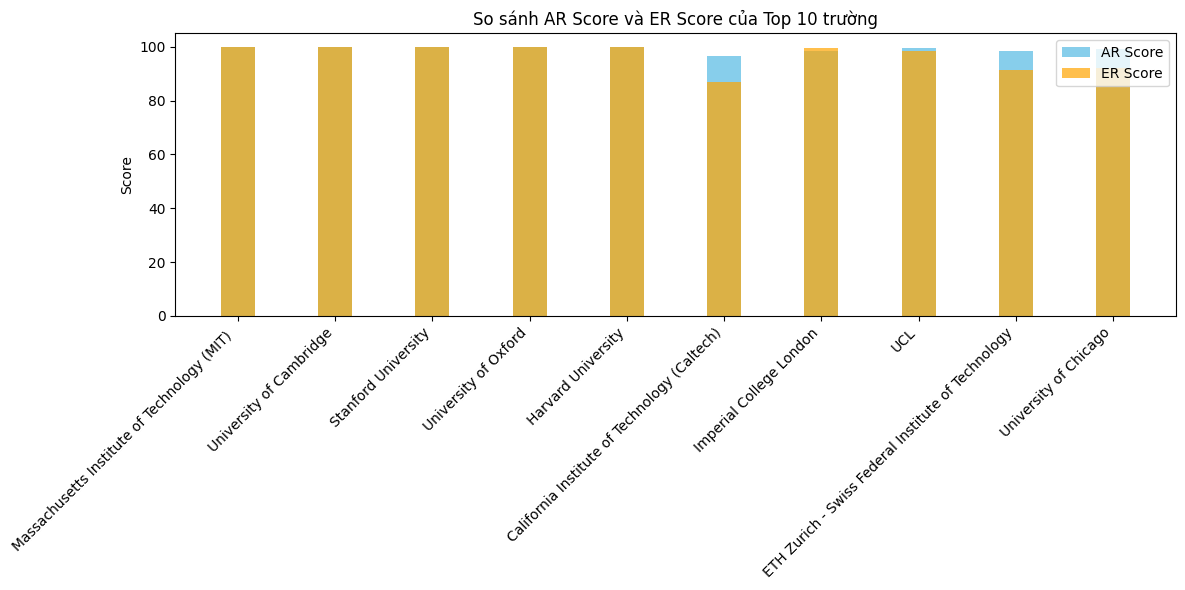

In [ ]:
top10 = df.head(10)

# Vẽ biểu đồ cột so sánh AR Score và ER Score
plt.figure(figsize=(12,6))
x = top10['institution']
width = 0.35

plt.bar(x, top10['ar score'], width, label='AR Score', color='skyblue')
plt.bar(x, top10['er score'], width, label='ER Score', color='orange', alpha=0.7)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Score')
plt.title('So sánh AR Score và ER Score của Top 10 trường')
plt.legend()
plt.tight_layout()
plt.show()

- Có một sự đồng nhất cao giữa danh tiếng học thuật và đánh giá từ nhà tuyển dụng tại các trường đại học hàng đầu. Tuy nhien, Caltech va ETH Zurich tuy AR cao nhung ER hoi thap.

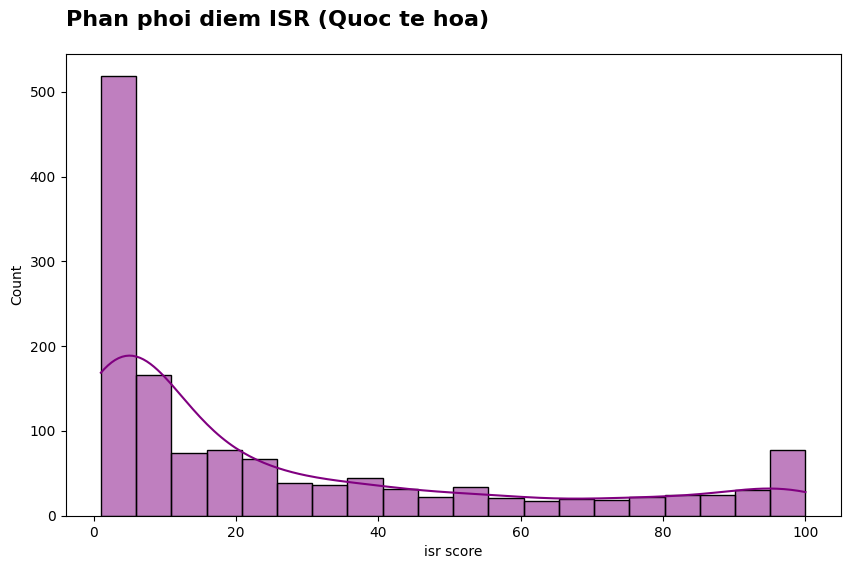

Phân tích chi tiết: Biểu đồ Histogram kết hợp đường cong mật độ (KDE) cho thấy mức độ tập trung điểm số của toàn bộ hệ thống. Việc quan sát hình dáng của đường cong giúp xác định xem phần lớn các trường đại học đang nằm ở phân khúc điểm trung bình hay có sự phân hóa cực đoan về hai phía, từ đó đưa ra các quyết định định vị thương hiệu phù hợp với năng lực thực tế.


In [ ]:
# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('UNI.csv')

# Chuẩn hóa tên cột (đưa về chữ thường và xóa khoảng trắng thừa)
df.columns = [col.strip().lower() for col in df.columns]

# 2. Cấu hình kích thước biểu đồ
plt.figure(figsize=(10, 6))

# 3. Vẽ biểu đồ Histogram kết hợp đường cong mật độ (KDE)
# color='purple' tương ứng với màu tím trong ảnh của bạn
sns.histplot(df['isr score'], bins=20, kde=True, color='purple')

# 4. Thêm tiêu đề và nhãn trục
plt.title('Phan phoi diem ISR (Quoc te hoa)', fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel('isr score')
plt.ylabel('Count')

# 5. Hiển thị biểu đồ
plt.show()

# 6. In đoạn phân tích (Caption) ngay dưới biểu đồ trong Notebook
print("Phân tích chi tiết: Biểu đồ Histogram kết hợp đường cong mật độ (KDE) cho thấy mức độ tập trung điểm số "
      "của toàn bộ hệ thống. Việc quan sát hình dáng của đường cong giúp xác định xem phần lớn các trường đại học "
      "đang nằm ở phân khúc điểm trung bình hay có sự phân hóa cực đoan về hai phía, từ đó đưa ra các quyết định "
      "định vị thương hiệu phù hợp với năng lực thực tế.")

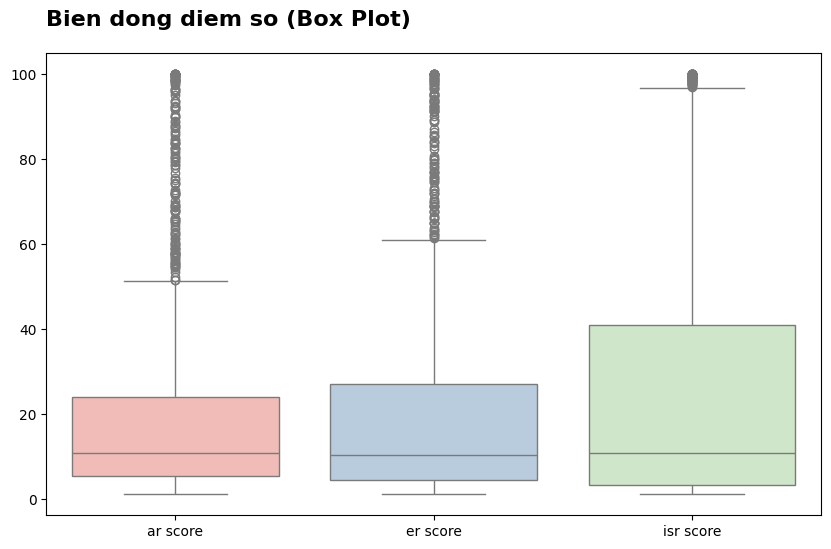

Phân tích chi tiết: Biểu đồ hộp giúp nhận diện độ lệch và giá trị ngoại lai của từng tiêu chí...


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['ar score', 'er score', 'isr score']], palette="Pastel1")
plt.title('Bien dong diem so (Box Plot)', fontsize=16, fontweight='bold', loc='left', pad=20)
plt.show()

print("Phân tích chi tiết: Biểu đồ hộp giúp nhận diện độ lệch và giá trị ngoại lai của từng tiêu chí...")

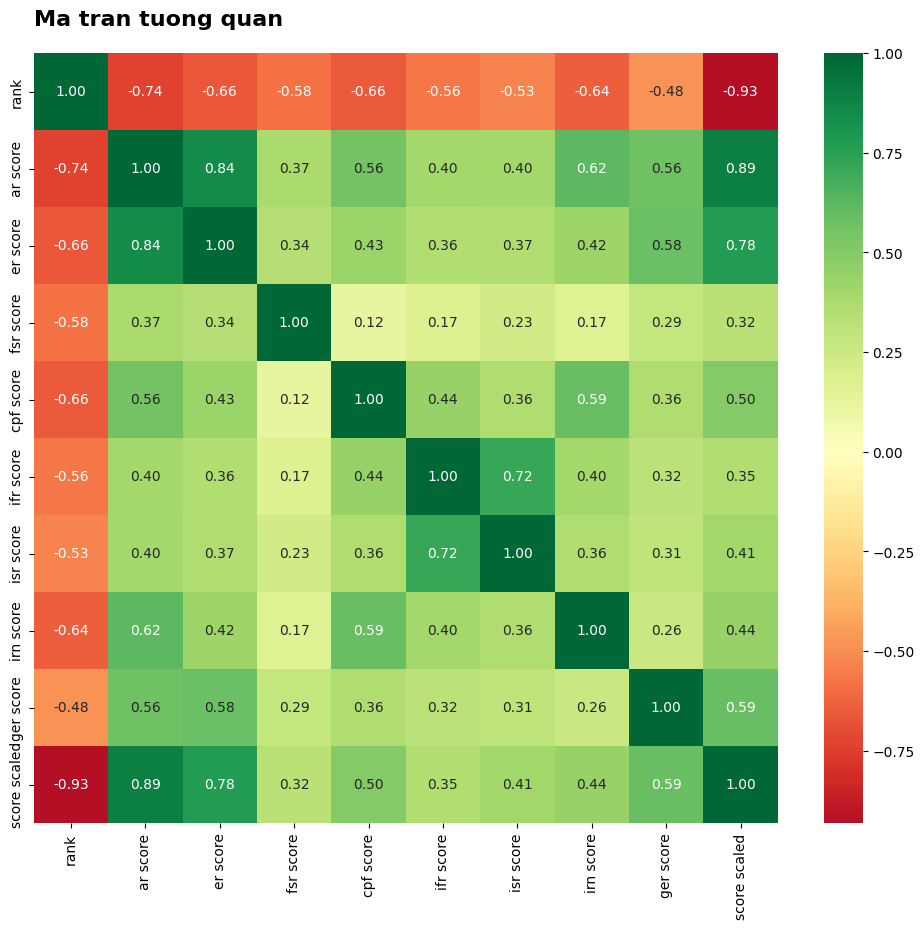

Phân tích chi tiết: Ma trận Heatmap cung cấp cái nhìn tổng thể về mối liên hệ cộng hưởng giữa các biến số. 
Hệ số tương quan càng gần 1.00 thể hiện các chỉ số này hỗ trợ lẫn nhau rất mạnh. Nhà chiến lược có thể dựa vào đây 
để xác định 'đòn bẩy': đầu tư vào một chỉ số then chốt để kéo theo sự tăng trưởng của các chỉ số liên quan khác.


In [ ]:
# 1. Cấu hình kích thước
plt.figure(figsize=(12, 10))

# 2. Tính toán ma trận tương quan cho các biến số
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# 3. Vẽ Heatmap với bảng màu Red-Yellow-Green (RdYlGn)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdYlGn', center=0)

# 4. Thêm tiêu đề
plt.title('Ma tran tuong quan', fontsize=16, fontweight='bold', loc='left', pad=20)

# 5. Hiển thị
plt.show()

# Chú thích phân tích
print("""Phân tích chi tiết: Ma trận Heatmap cung cấp cái nhìn tổng thể về mối liên hệ cộng hưởng giữa các biến số. 
Hệ số tương quan càng gần 1.00 thể hiện các chỉ số này hỗ trợ lẫn nhau rất mạnh. Nhà chiến lược có thể dựa vào đây 
để xác định 'đòn bẩy': đầu tư vào một chỉ số then chốt để kéo theo sự tăng trưởng của các chỉ số liên quan khác.""")

TRAIN AND TEST 

In [24]:
#Làm sạch dữ liệu quan trọng nhất
# Loại bỏ các dòng mà cột mục tiêu 'score scaled' bị trống
df_model = df.dropna(subset=['score scaled']).copy()

# 3. Chọn tất cả các cột kiểu số làm Features
# Loại bỏ các cột không phải là biến độc lập (như rank hoặc score tổng)
target = 'score scaled'
features = df_model.select_dtypes(include=[np.number]).columns.tolist()
cols_to_exclude = [target, 'rank', 'score', 'unnamed: 0']
features = [f for f in features if f not in cols_to_exclude]

print(f"Các trường được dùng để dự đoán: {features}")

# 4. Xử lý NaN trong các Features (điền giá trị trung bình)
df_model[features] = df_model[features].fillna(df_model[features].mean())

# 5. Tách X và y
X = df_model[features]
y = df_model[target]

# 6. Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Các trường được dùng để dự đoán: ['ar score', 'er score', 'fsr score', 'cpf score', 'ifr score', 'isr score', 'irn score', 'ger score', 'international influence']


In [25]:
# Khởi tạo mô hình Random Forest
# Bạn có thể dùng best_n từ biểu đồ tối ưu hóa ở trên (ví dụ n=91)
model_final = RandomForestRegressor(n_estimators=91, random_state=42)
model_final.fit(X_train, y_train)

# Dự báo trên tập Test
y_pred = model_final.predict(X_test)

# Tính toán các chỉ số lỗi
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Kết quả huấn luyện:")
print(f"- RMSE (Sai số trung bình): {rmse:.4f}")
print(f"- R2 Score (Độ chính xác): {r2*100:.2f}%")

Kết quả huấn luyện:
- RMSE (Sai số trung bình): 4.7169
- R2 Score (Độ chính xác): 94.78%


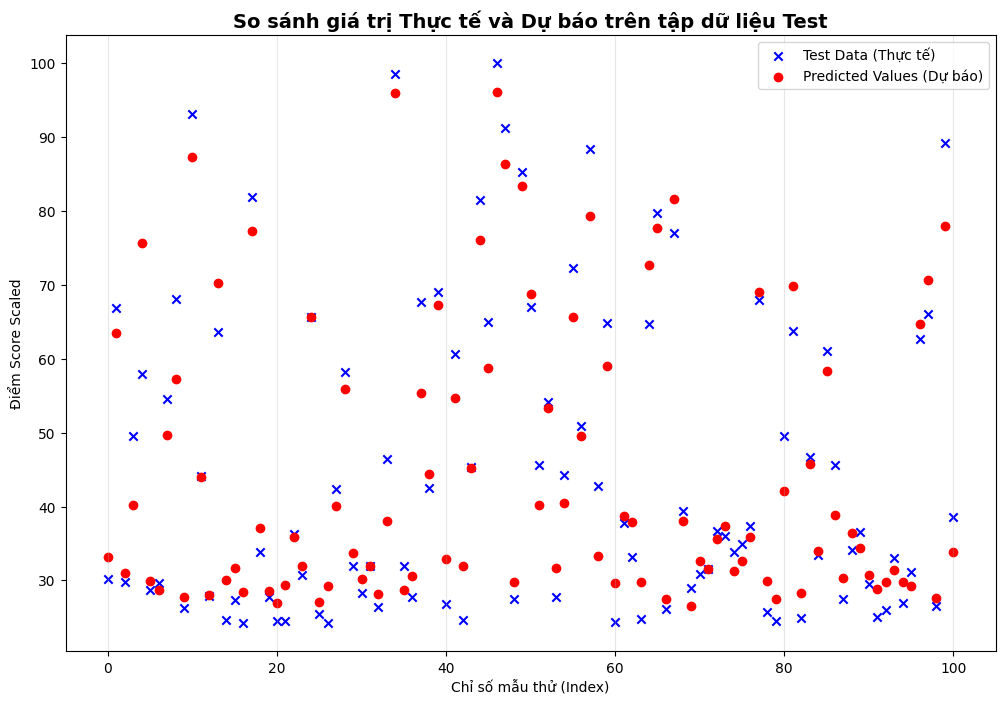

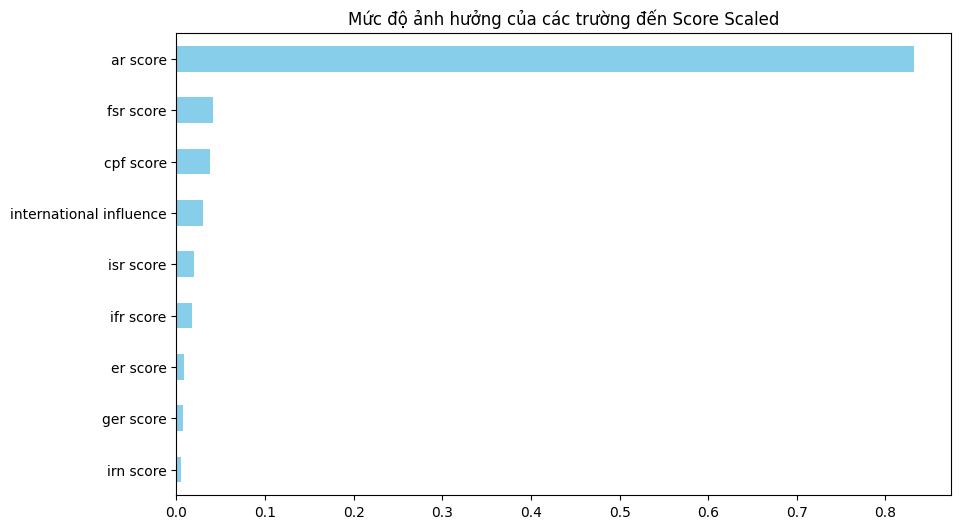

In [26]:
# --- Biểu đồ So sánh Thực tế vs Dự báo ---
plt.figure(figsize=(12, 8))
v = range(len(y_test))

plt.scatter(v, y_test, color='b', marker='x', label="Test Data (Thực tế)")
plt.scatter(v, y_pred, color='r', marker='o', label="Predicted Values (Dự báo)")

plt.title('So sánh giá trị Thực tế và Dự báo trên tập dữ liệu Test', fontsize=14, fontweight='bold')
plt.xlabel('Chỉ số mẫu thử (Index)')
plt.ylabel('Điểm Score Scaled')
plt.legend(loc="upper right")
plt.grid(axis='x', alpha=0.3)
plt.show()

# --- Biểu đồ Mức độ quan trọng của các trường (Feature Importance) ---
plt.figure(figsize=(10, 6))
importances = pd.Series(model_final.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='skyblue')
plt.title('Mức độ ảnh hưởng của các trường đến Score Scaled')
plt.show()

RANDOM FOREST 


Số lượng cây tối ưu: 150


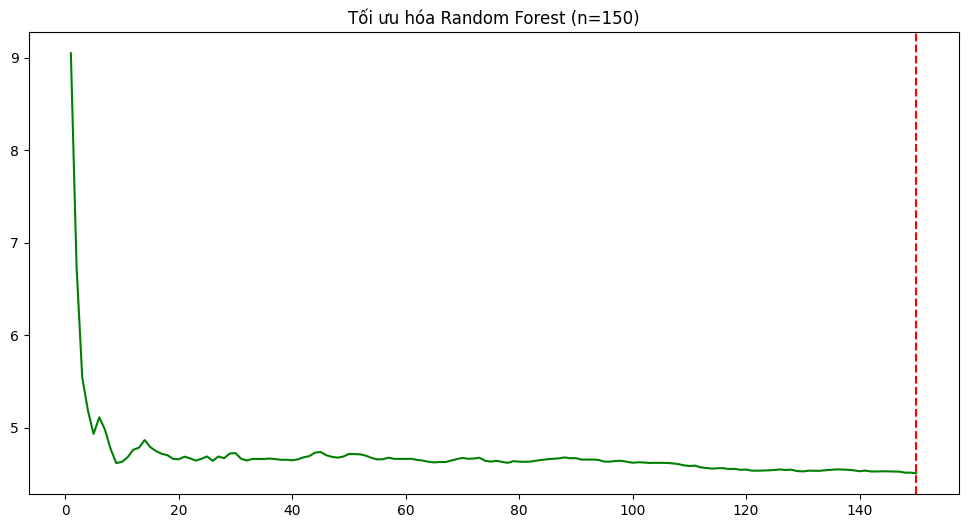

: 

In [ ]:

# Đọc dữ liệu
df = pd.read_csv("UNI.csv")
df.columns = [col.strip().lower() for col in df.columns]

# BƯỚC QUAN TRỌNG: Chỉ xóa hàng nếu cột mục tiêu 'score scaled' bị trống
df_clean = df.dropna(subset=['score scaled']).copy()

# Chọn Features: Lấy tất cả cột số trừ các cột định danh
target = 'score scaled'
features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cols_to_remove = [target, 'score', 'rank', 'unnamed: 0']
features = [f for f in features if f in df_clean.columns and f not in cols_to_remove]

X = df_clean[features]
y = df_clean[target]

# Điền giá trị thiếu bằng trung bình (Đồng bộ với Dashboard)
X = X.fillna(X.mean(numeric_only=True))

# Chia dữ liệu với random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Quét tìm n_estimators
rmse_list = []
for n in range(1, 151):
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    rmse_list.append(np.sqrt(mean_squared_error(y_test, rf.predict(X_test))))

best_n = np.argmin(rmse_list) + 1
print(f"Số lượng cây tối ưu: {best_n}")

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(range(1, 151), rmse_list, color='green')
plt.axvline(x=best_n, color='red', linestyle='--')
plt.title(f'Tối ưu hóa Random Forest (n={best_n})')
plt.show()